## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib
import numpy as np

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
import skrom.problem_classes.masterclass as master
from skrom.rom.rom_error_est import *

problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")

PETSc available: True


### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.generate_vtk import visualize2D 
set_color_palette();
import sci_mplstyle_package

In [4]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation

In [5]:
# Offline stage
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation(num_snapshots=64)

    sim.run_simulation()  # Run the simulation in parallel using 8 workers


Snap 1/128 params=[ 0.92119064  0.40518899  0.41078728  0.7858698   2.          2.68581285
  0.         10.         30.        ]

Snap 2/128 params=[ 0.45857138  0.97253593  0.87387338  3.49200419  2.          5.47734319
  0.         10.         30.        ]
Snap 3/128 params=[ 0.28049744  0.29985477  0.17542853  1.21456995  2.          3.7586953
  0.         10.         30.        ]
Snap 4/128 params=[ 0.77231458  0.6278925   0.6099563   2.50859365  2.          1.39361196
  0.         10.         30.        ]
Snap 5/128 params=[ 0.63049527  0.17230546  0.97587114  2.01317973  2.          2.0075692
  0.         10.         30.        ]
Snap 6/128 params=[ 0.19336172  0.75541777  0.54071088  1.71683507  2.          4.84012376
  0.         10.         30.        ]
Snap 7/128 params=[ 0.36772778  0.53075733  0.7334804   3.98680795  2.          3.1742043
  0.         10.         30.        ]
Snap 8/128 params=[ 0.77604797  0.84698475  0.2697633   0.28226171  2.          0.66263944
  0.   

### Load Simulation Data

In [6]:
# Load data
# fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=Path().resolve() / "ROM_data")
# LS = np.asarray(fos_solutions)
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\reaction_diffusion\problem_1\ROM_data


### Generate training solution dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


128


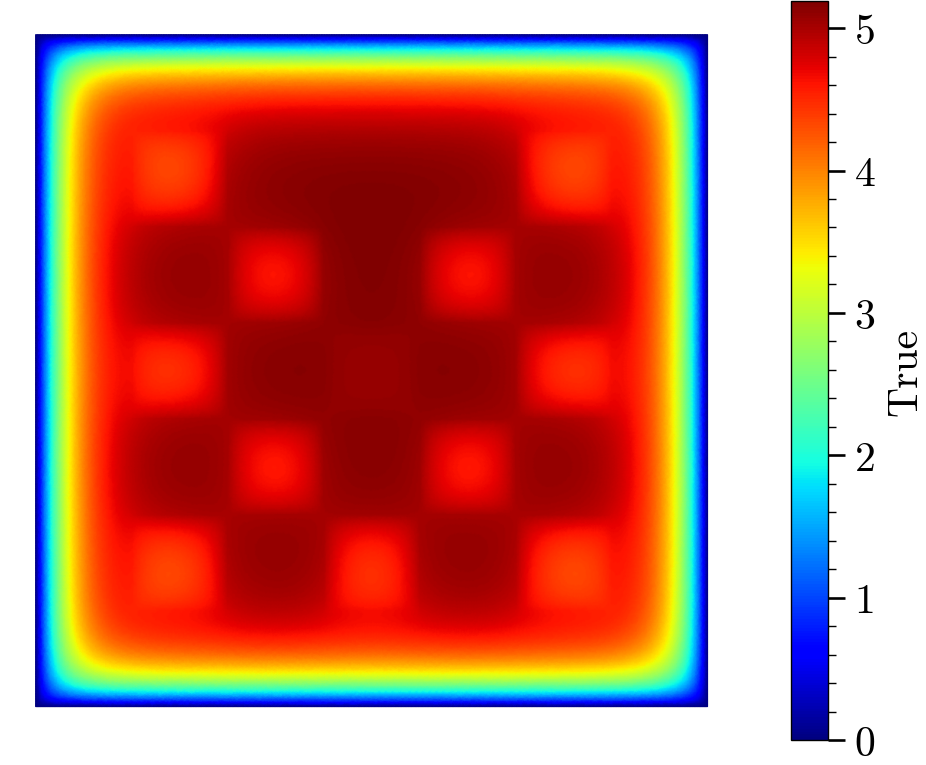

In [8]:
if visualize:
    visualize2D(LS_test[7],rom_data.basis)

### Mean Subtraction

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Performing SVD on training snapshots

Number of modes selected: 30


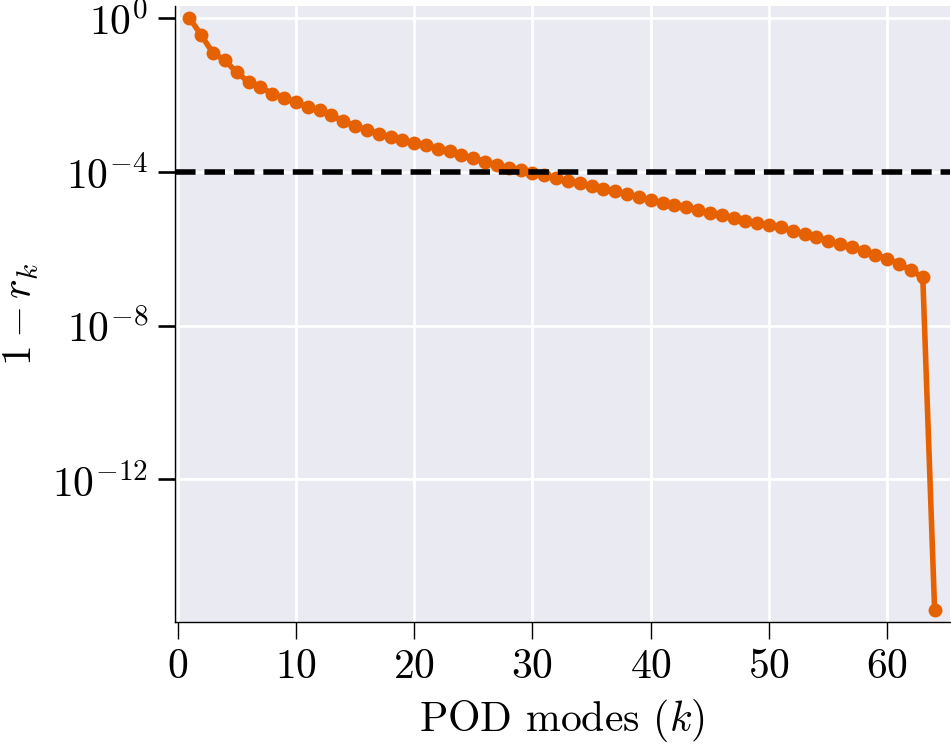

In [10]:
if run_svd:

    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
    plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

    # Perform Singular Value Decomposition (SVD) for POD mode selection
    # SVD decomposes the mean-centered training data to find optimal basis functions
    n_sel, U = svd_mode_selector(LS_train_ms,    # Input: mean-centered training snapshots
                                tolerance=1e-4,    # Convergence criterion for mode selection
                                modes=True)        # Return both number of modes and basis vectors


    # Extract the selected POD basis vectors (spatial modes)
    # V_sel contains the first n_sel most energetic POD modes
    # Shape: [N_dof, n_sel] - each column is a spatial basis function
    V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

    # Set axis labels for the POD energy plot (generated by svd_mode_selector)
    plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
    plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation

In [11]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean, test_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\reaction_diffusion\problem_1\ROM_data


In [13]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/64 params=[ 0.23346968  0.93363576  0.99907986  0.53482098  2.          4.3263074
  0.         10.         30.        ]

Snap 2/64 params=[ 0.58741507  0.23590717  0.18704258  3.420159    2.          1.15710813
  0.         10.         30.        ]
Snap 3/64 params=[ 0.81110797  0.58501633  0.75988607  1.77241787  2.          1.67808201
  0.         10.         30.        ]
Snap 4/64 params=[ 0.45540434  0.33294076  0.42626217  2.15174294  2.          4.83556578
  0.         10.         30.        ]
Snap 5/64 params=[ 0.39139827  0.72383336  0.31652041  2.61428313  2.          3.06680214
  0.         10.         30.        ]
Snap 6/64 params=[ 0.99187641  0.53162349  0.86959623  1.49273907  2.          0.25944213
  0.         10.         30.        ]
Snap 7/64 params=[ 0.76556909  0.85092108  0.52749313  3.81284349  2.          2.94931178
  0.         10.         30.        ]
Snap 8/64 params=[ 0.16333357  0.20612204  0.65865274  0.20097443  2.          5.72151873
  0.         1

In [14]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 3.9008e-01
Relative L2 Error:        1.3978e-03
L∞ Error:                 6.3720e-01
Relative L∞ Error:        5.6322e-03
RMSE:                     1.4155e-02
MAE:                      2.8645e-03

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       0.9997

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    8.7397e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 4.6877e-06
Max Rel L2 Error over time/parameter: 4.2466e-05
Min Rel L2 Error over time/parameter: 8.6187e-07
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

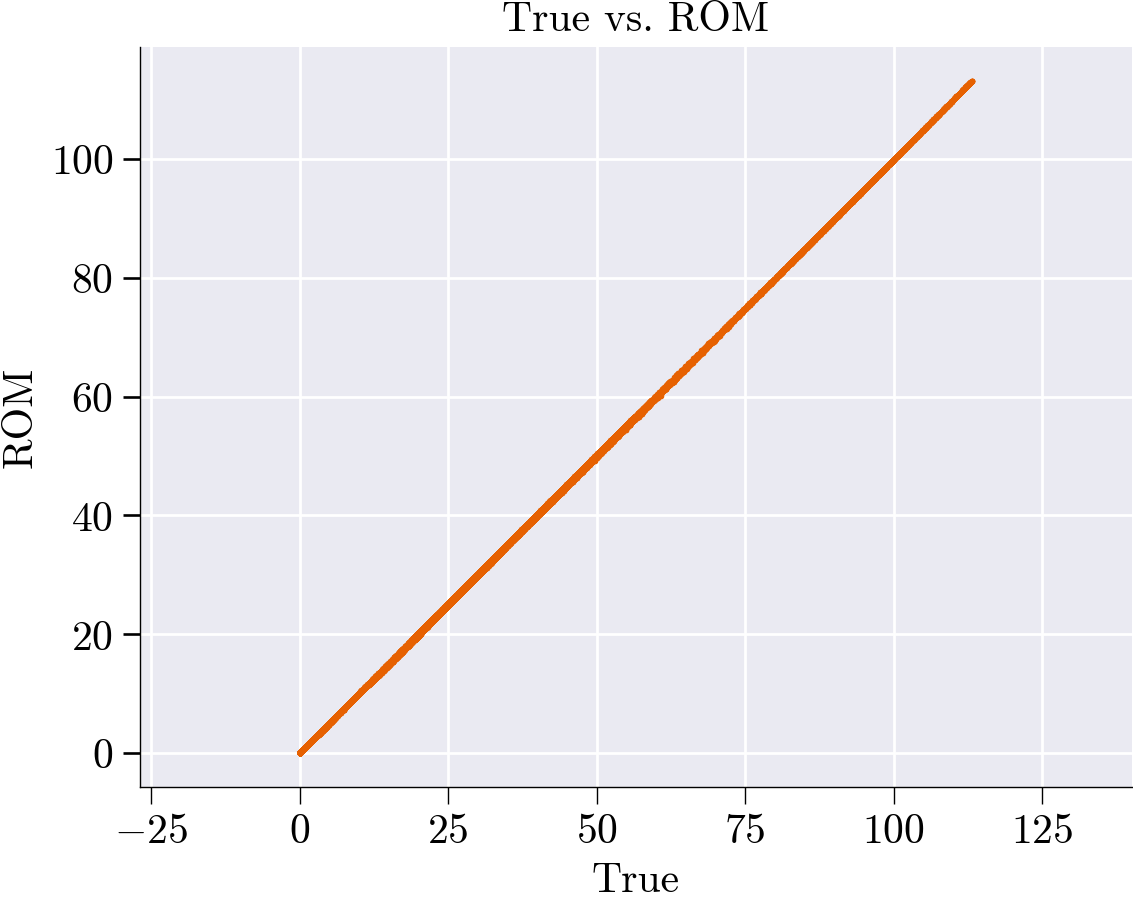

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


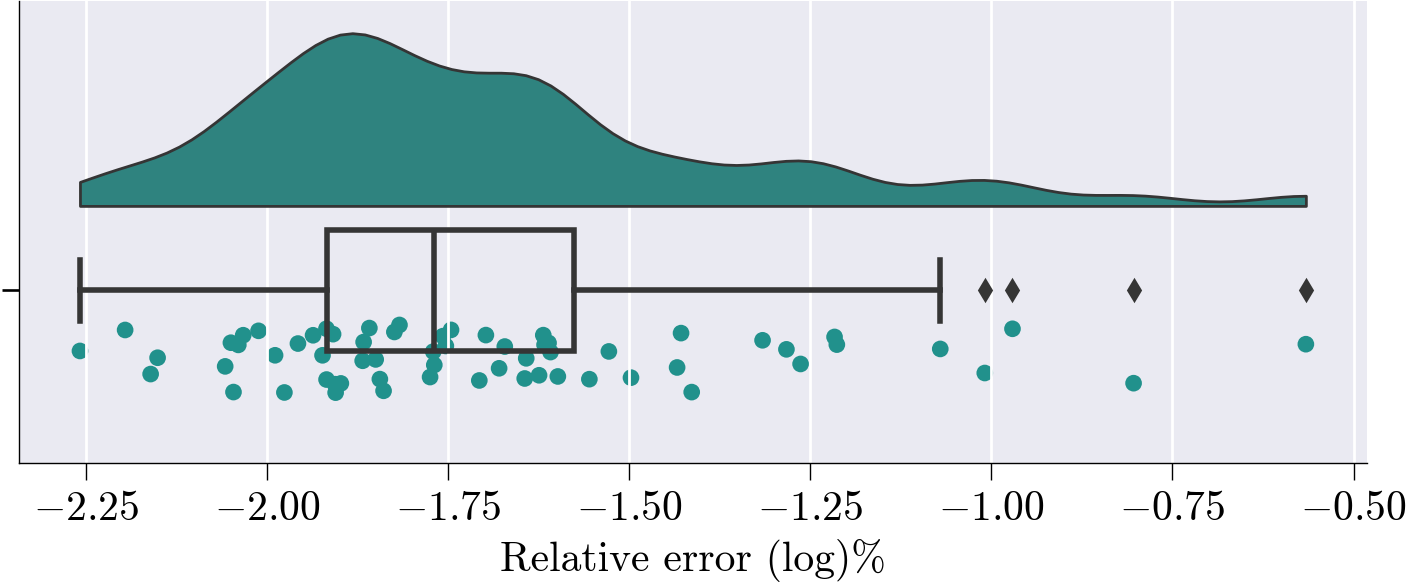

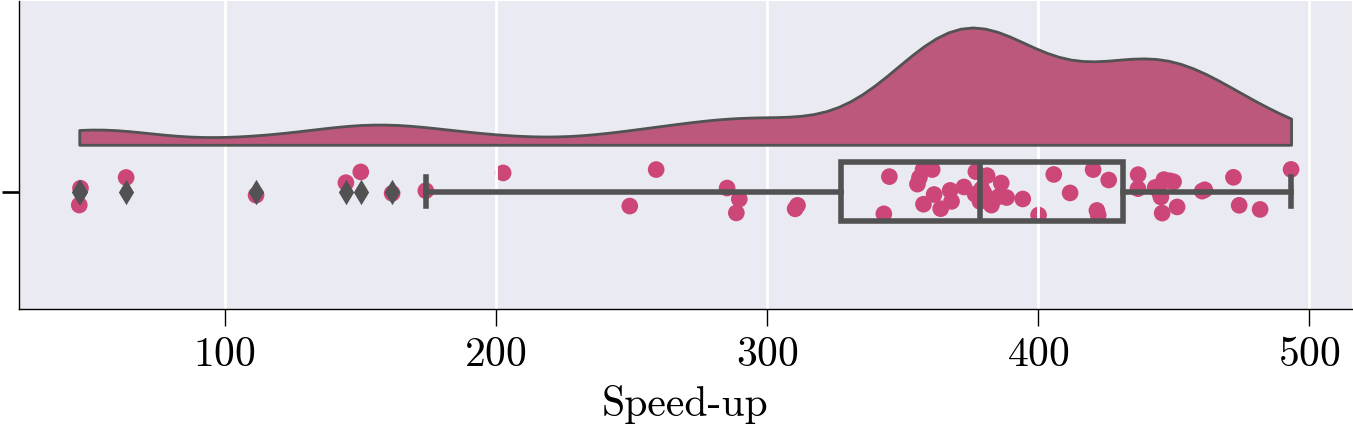

In [15]:
# --- ROM error analysis ---
if rom_report:
    
    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test[1:],                   # full-order (true) solution snapshots
        LS_rom[1:],              # hyper-ROM-generated solution snapshots
        rom.rom_error[1:],   # precomputed relative error of the hyper-ROM
        rom.speed_up[1:],         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )
